# K Nearest Neighbours (XAI Analysis)


**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** KNN 

**Task:** Predict Pokémon primary type from sprite color features (17 classes, 42 features)

In [19]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image
import shap
import lime
import lime.lime_tabular
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# 1. Get the current working directory
cwd = Path.cwd()

# 2. Locate the 'src' directory dynamically
# This works whether Jupyter's CWD is the 'notebooks' folder OR the project root
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")

# 3. Insert at position 0 to prioritize your local module over installed packages
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Now import should work seamlessly
import common

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

# 1. Dataset Load and Preparation

In [20]:
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

X_train, X_test, y_train, y_test, split_idx = common.get_train_test_split(df)
scaler = common.get_scaler(X_train)

# Scaling is CRITICAL for KNN (distance-based)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("Note: KNN is distance-based. StandardScaler is essential to prevent high-variance")
print("      features from dominating Euclidean distance.")

Train: 820 | Test: 205
Note: KNN is distance-based. StandardScaler is essential to prevent high-variance
      features from dominating Euclidean distance.


# 2. ML Model Training

In [21]:
cv = common.get_cv_splitter(n_splits=5)
param_grid = {
    "n_neighbors": [3, 5, 8, 13, 21, 34, 55, 89],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"],
    "p": [1, 2],
}
base_knn = KNeighborsClassifier()
grid_search = GridSearchCV(base_knn, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best CV f1_macro: 0.2176


Test accuracy: 0.2488
Test f1_macro: 0.1871


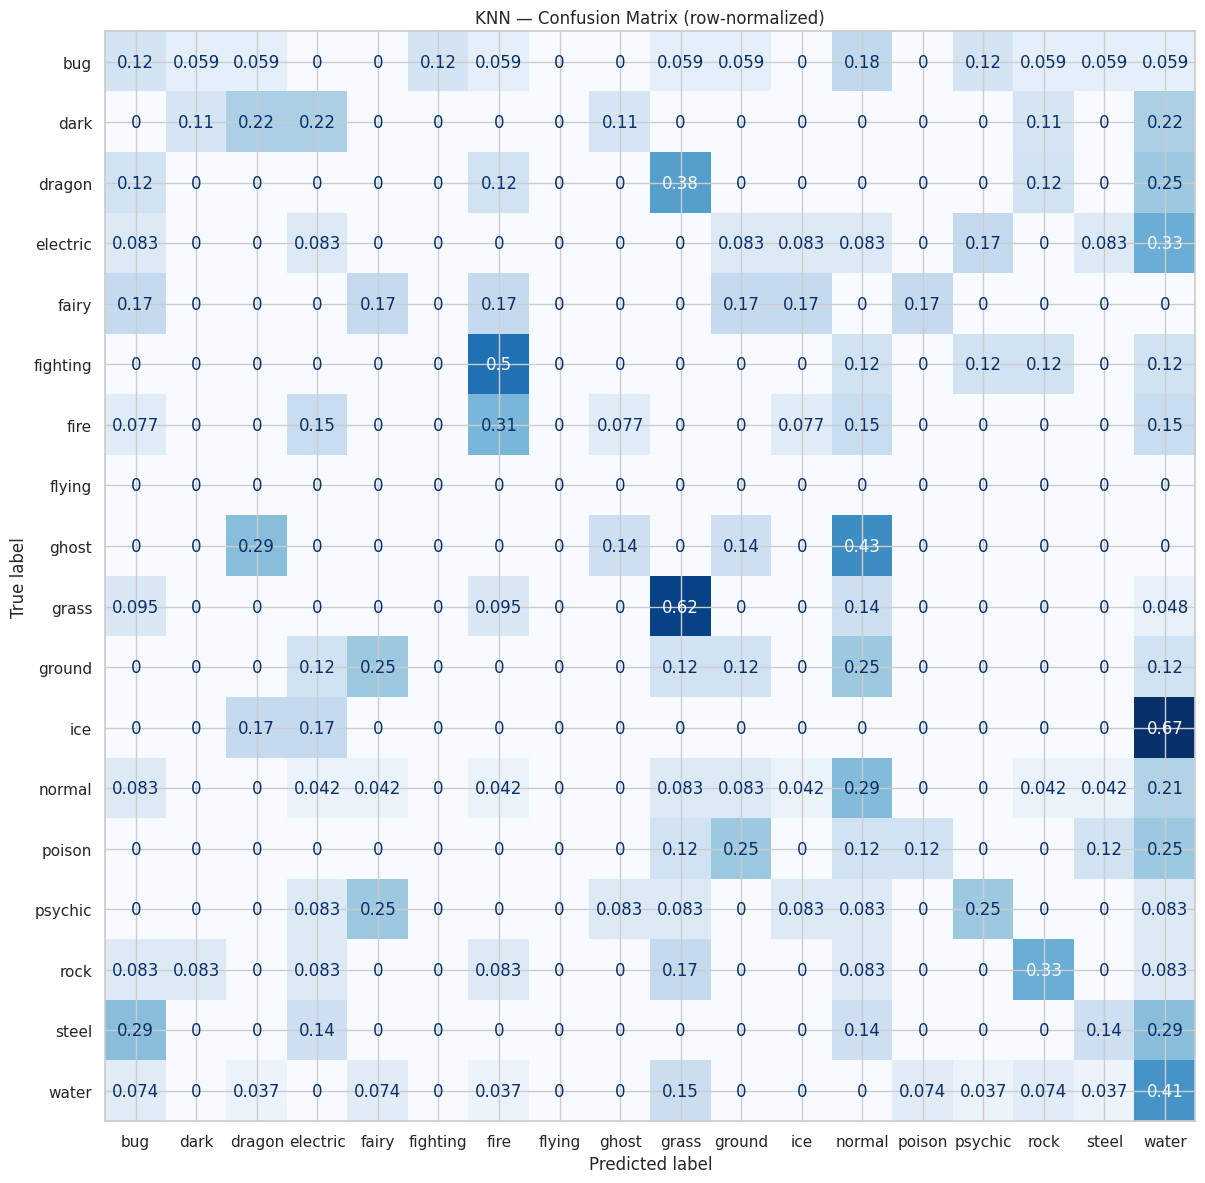

              precision    recall  f1-score   support

         bug       0.13      0.12      0.12        17
        dark       0.33      0.11      0.17         9
      dragon       0.00      0.00      0.00         8
    electric       0.09      0.08      0.09        12
       fairy       0.11      0.17      0.13         6
    fighting       0.00      0.00      0.00         8
        fire       0.25      0.31      0.28        13
      flying       0.00      0.00      0.00         0
       ghost       0.25      0.14      0.18         7
       grass       0.46      0.62      0.53        21
      ground       0.11      0.12      0.12         8
         ice       0.00      0.00      0.00         6
      normal       0.27      0.29      0.28        24
      poison       0.25      0.12      0.17         8
     psychic       0.33      0.25      0.29        12
        rock       0.36      0.33      0.35        12
       steel       0.17      0.14      0.15         7
       water       0.28    

In [22]:
knn = grid_search.best_estimator_
y_pred = knn.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, f1_score
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test f1_macro: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred, int_to_type,
                              title="KNN \u2014 Confusion Matrix (row-normalized)", ax=ax)
plt.show()
common.print_classification_report(y_test, y_pred, int_to_type)

In [23]:
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score as f1_score_sk

# Save KNN predictions for cross-model comparison in notebook 3
save_path = Path("data/processed/knn_test_results.json")
save_path.parent.mkdir(parents=True, exist_ok=True)
knn_to_save = {
    "y_test":       y_test.tolist(),
    "y_pred":       y_pred.tolist(),
    "test_indices": split_idx["test_idx"].tolist(),
    "best_params":  grid_search.best_params_,
    "accuracy":     float(accuracy_score(y_test, y_pred)),
    "f1_macro":     float(f1_score_sk(y_test, y_pred, average="macro", zero_division=0)),
}
with open(save_path, "w") as f:
    json.dump(knn_to_save, f)
print(f"KNN results saved to {save_path}")

KNN results saved to data/processed/knn_test_results.json


# 3. ML Explanation

## 3.1 Global Explanations. Feature Importance

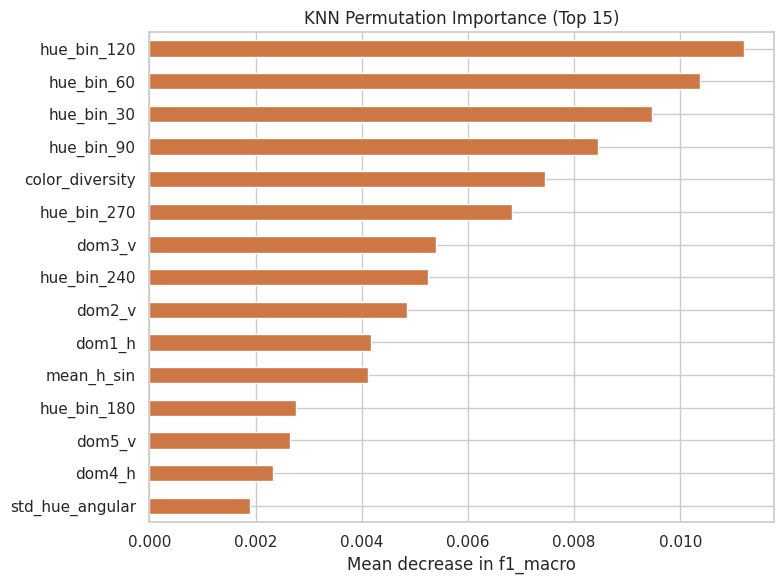

In [24]:
perm_imp = permutation_importance(knn, X_test_scaled, y_test, n_repeats=20,
                                   random_state=common.RANDOM_STATE, scoring="f1_macro")
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)
fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("KNN Permutation Importance (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout(); plt.show()

Computing SHAP values...


100%|██████████| 80/80 [00:04<00:00, 17.60it/s]


Done.


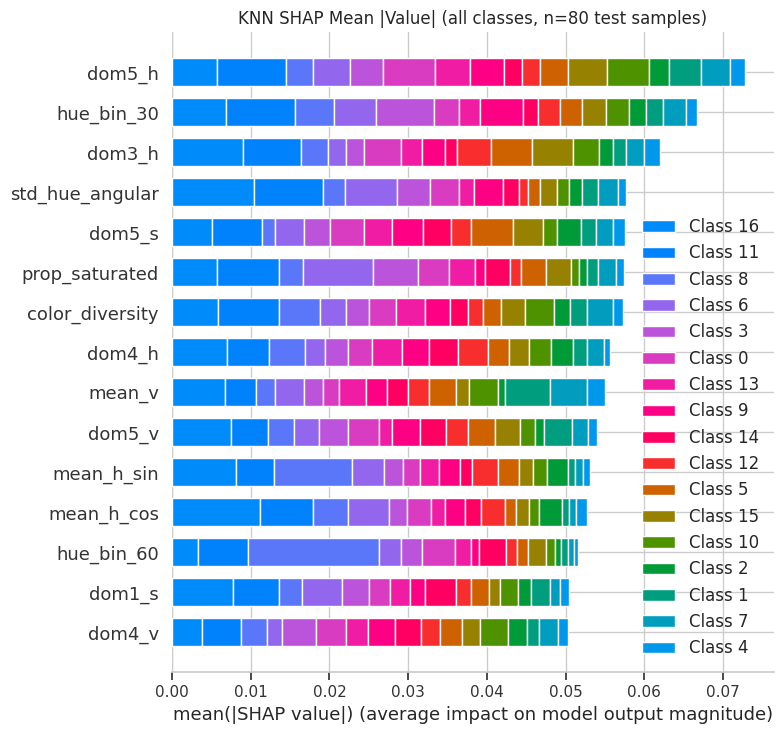

Note: SHAP computed on 80 test instances using KernelExplainer with
k-means background summary (k=100). Approximate but representative.


In [25]:
print("Computing SHAP values...")
background = shap.kmeans(X_train_scaled.values, 100)

# Subset of test set for summary plots
np.random.seed(common.RANDOM_STATE)
shap_sample_idx = np.random.choice(len(X_test_scaled), size=80, replace=False)
X_test_shap = X_test_scaled.iloc[shap_sample_idx]

kernel_explainer = shap.KernelExplainer(knn.predict_proba, background)
shap_values_knn = kernel_explainer.shap_values(X_test_shap.values, nsamples=200)
# shap_values_knn: list of n_classes arrays, each (80, n_features)
print("Done.")

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values_knn, X_test_shap, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("KNN SHAP Mean |Value| (all classes, n=80 test samples)")
plt.tight_layout(); plt.show()

print("Note: SHAP computed on 80 test instances using KernelExplainer with")
print("k-means background summary (k=100). Approximate but representative.")

KNN's permutation importance and SHAP rankings differ subtly from the Decision Tree. KNN relies more on histogram bin features (`hue_bin_X`) because they directly encode the proportion of pixels in each hue range: a natural similarity measure for distance-based classification. The dominant hue features (`dom1_h`) rank lower because small angular differences in centroid position can map to large Euclidean distances after scaling.

## 3.2 Local Explanations

In [26]:
EXPLAIN_IDS = common.EXPLAIN_IDS.copy()

fallbacks = {"correct_clear": 9, "correct_surprise": None,
             "misclass_secondary": None, "misclass_wrong": None}
for k, v in fallbacks.items():
    if EXPLAIN_IDS[k] is None and v is not None:
        EXPLAIN_IDS[k] = v
explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining:", explain_cases)

Explaining: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}



[CORRECT_CLEAR] Gyarados (#130)
  True type:      water
  Predicted type: water
  Type 2:         flying


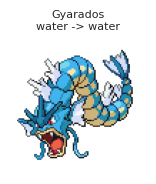


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Totodile             water        N/A            21.771
  Quaxwell             water        N/A            23.020
  Cobalion             steel        fighting       23.707
  Porygon              normal       N/A            24.027
  Sneasel              dark         ice            24.154


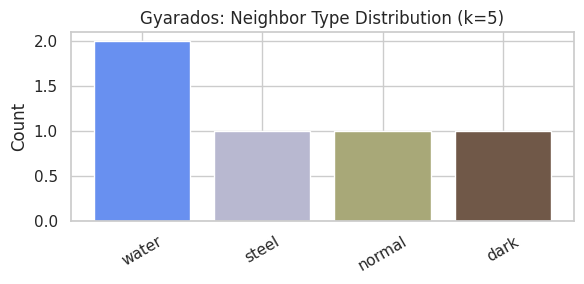

  SHAP: instance not in precomputed sample (skipping waterfall)


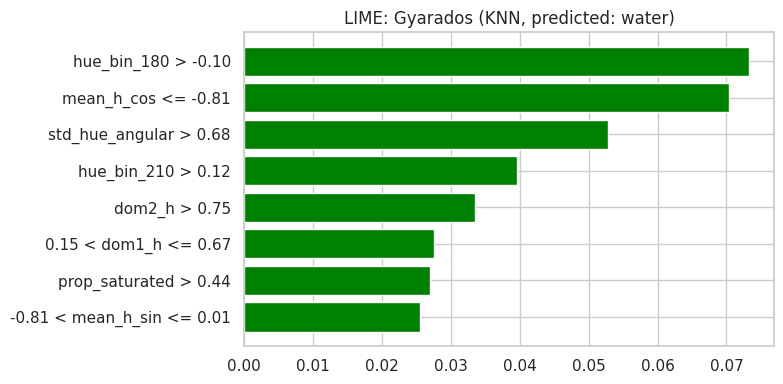


[CORRECT_SURPRISE] Iron-crown (#1023)
  True type:      steel
  Predicted type: water
  Type 2:         psychic


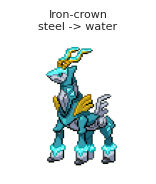


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Quaquaval            water        fighting       20.222
  Quaxwell             water        N/A            21.335
  Piplup               water        N/A            21.666
  Machamp              fighting     N/A            21.926
  Araquanid            water        bug            22.076


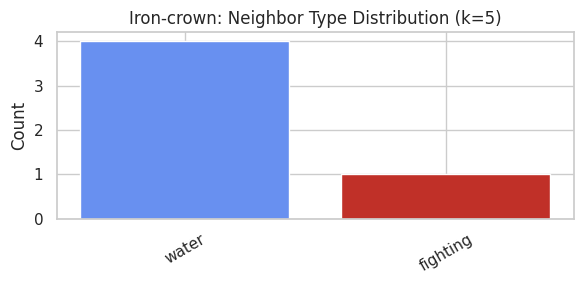

  SHAP: instance not in precomputed sample (skipping waterfall)


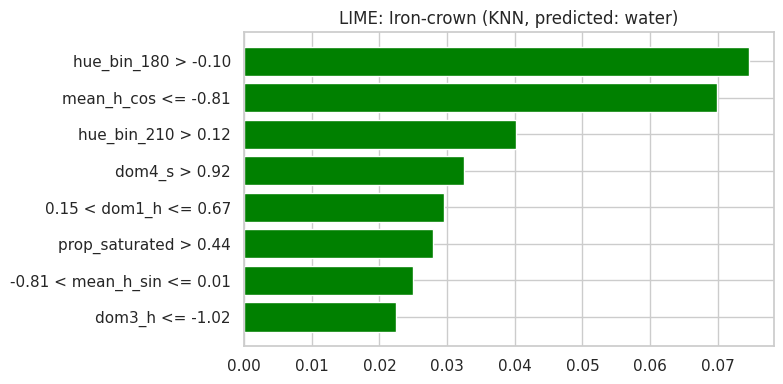


[MISCLASS_SECONDARY] Gengar (#94)
  True type:      ghost
  Predicted type: ghost
  Type 2:         poison


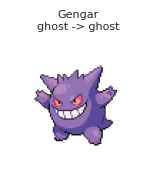


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Mismagius            ghost        N/A            20.000
  Muk                  poison       N/A            24.779
  Mewtwo               psychic      N/A            25.828
  Revavroom            steel        poison         25.878
  Goodra               dragon       N/A            26.345


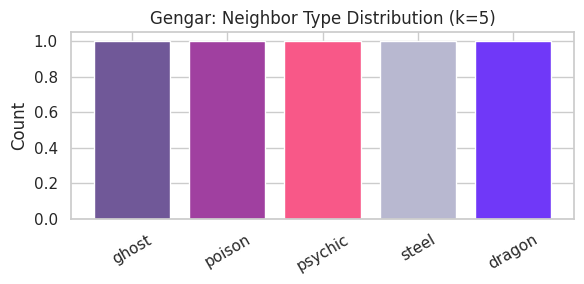

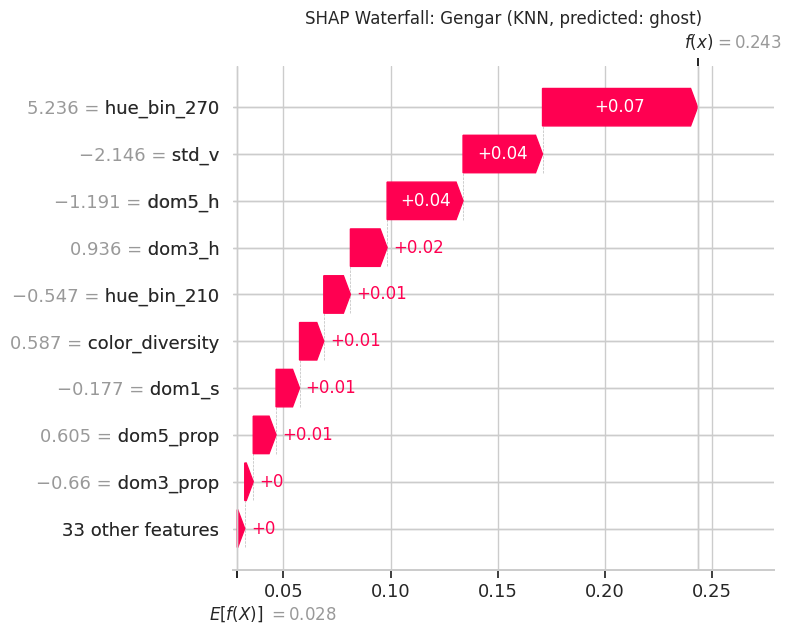

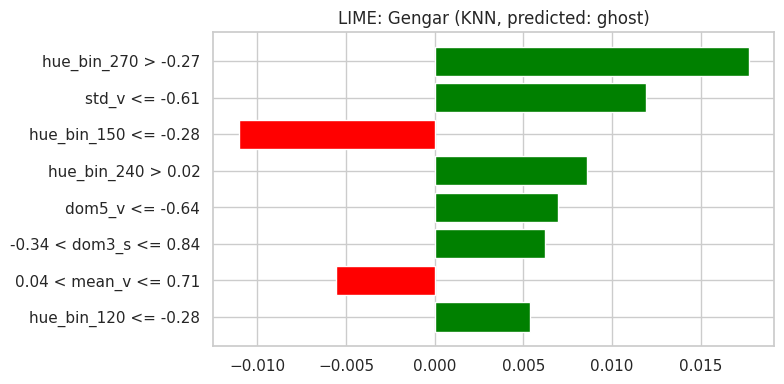


[MISCLASS_WRONG] Gholdengo (#1000)
  True type:      steel
  Predicted type: bug
  Type 2:         ghost


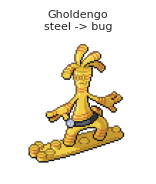


  5 Nearest Neighbors (scaled feature space):
  Name                 Type1        Type2            Dist
  -------------------------------------------------------
  Weedle               bug          poison         14.990
  Psyduck              water        N/A            18.048
  Charmeleon           fire         N/A            19.262
  Spinda               normal       N/A            20.080
  Raichu               electric     N/A            20.403


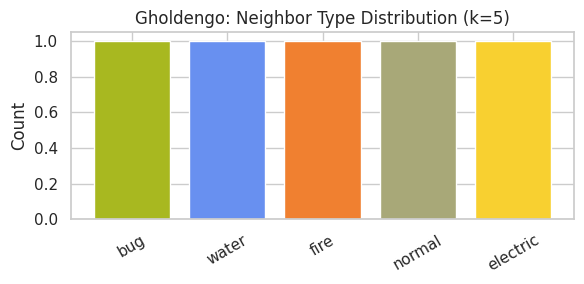

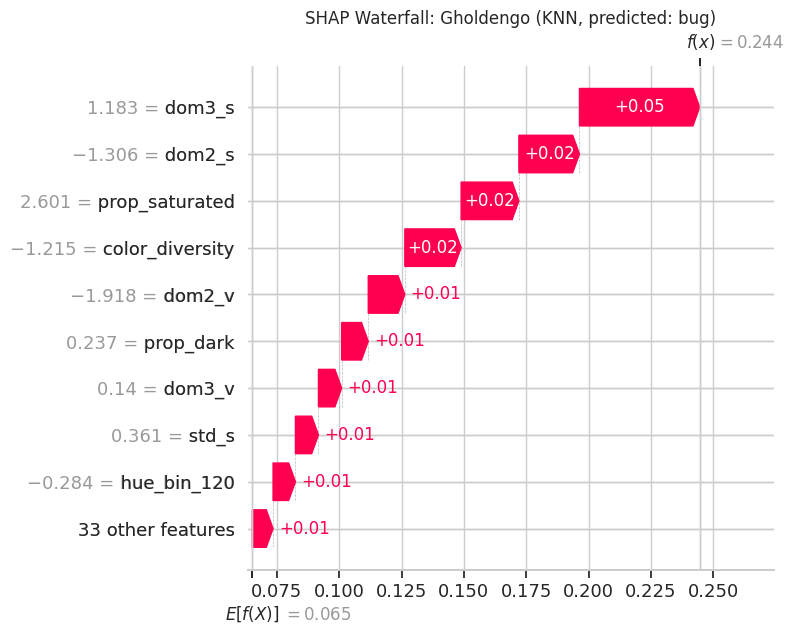

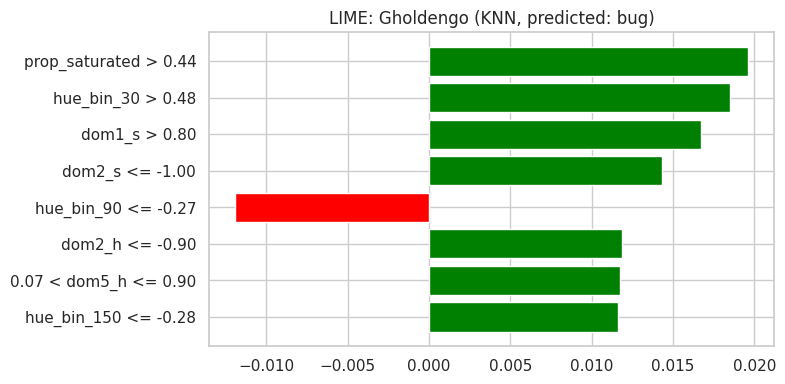

In [27]:
def explain_instance_knn(pokemon_id: int, label: str) -> None:
    """Full local explanation: sprite, neighbors, SHAP waterfall, LIME."""
    row_mask = df["id"] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found"); return

    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    match = np.where(test_indices == np.where(df.index == df_pos)[0][0])[0]
    if len(match) == 0:
        print(f"Pokemon {pokemon_id} is in the training set, not the test set"); return

    i = match[0]
    x_instance = X_test_scaled.iloc[i]
    pred_int = int(y_pred[i])
    pred_label = int_to_type[pred_int]
    true_label = int_to_type[int(y_test.iloc[i])]

    print(f"\n{'='*60}")
    print(f"[{label.upper()}] {row['name'].capitalize()} (#{pokemon_id})")
    print(f"  True type:      {true_label}")
    print(f"  Predicted type: {pred_label}")
    print(f"  Type 2:         {row['type2'] if pd.notna(row['type2']) else 'N/A'}")

    # Sprite
    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2, 2))
        ax.imshow(Image.open(sprite_path).convert("RGBA")); ax.axis("off")
        ax.set_title(f"{row['name'].capitalize()}\n{true_label} -> {pred_label}", fontsize=8)
        plt.tight_layout(); plt.show()

    # Nearest neighbors
    k = knn.n_neighbors
    distances, neighbor_indices = knn.kneighbors(x_instance.values.reshape(1, -1), n_neighbors=k)
    neighbor_df_indices = X_train_scaled.index[neighbor_indices[0]]
    print(f"\n  {k} Nearest Neighbors (scaled feature space):")
    print(f"  {'Name':<20} {'Type1':<12} {'Type2':<12} {'Dist':>8}")
    print(f"  {'-'*55}")
    for ni, dist in zip(neighbor_df_indices, distances[0]):
        nb = df.loc[ni]
        t2 = nb["type2"] if pd.notna(nb["type2"]) else "N/A"
        print(f"  {nb['name'].capitalize():<20} {nb['type1']:<12} {t2:<12} {dist:>8.3f}")

    # Neighbor type distribution
    neighbor_types = [df.loc[ni]["type1"] for ni in neighbor_df_indices]
    type_counts = pd.Series(neighbor_types).value_counts()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(type_counts.index, type_counts.values,
           color=[common.TYPE_COLORS.get(t, "#888") for t in type_counts.index],
           edgecolor="white")
    ax.set_title(f"{row['name'].capitalize()}: Neighbor Type Distribution (k={k})")
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()

    # SHAP waterfall
    shap_idx_in_sample = np.where(shap_sample_idx == i)[0]
    if len(shap_idx_in_sample) > 0:
        sample_i = shap_idx_in_sample[0]
        pred_pos = list(knn.classes_).index(pred_int)
        sv = shap_values_knn[sample_i, :, pred_pos]
        base = kernel_explainer.expected_value[pred_pos]
        exp_obj = shap.Explanation(
            values=sv, base_values=base,
            data=x_instance.values, feature_names=feature_cols
        )
        plt.figure()
        shap.plots.waterfall(exp_obj, show=False)
        plt.title(f"SHAP Waterfall: {row['name'].capitalize()} (KNN, predicted: {pred_label})")
        plt.tight_layout(); plt.show()
    else:
        print("  SHAP: instance not in precomputed sample (skipping waterfall)")

    # LIME
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=[int_to_type[j] for j in sorted(int_to_type)],
        mode="classification",
        random_state=common.RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, knn.predict_proba, num_features=8, top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(8, 4)
    plt.title(f"LIME: {row['name'].capitalize()} (KNN, predicted: {pred_label})")
    plt.tight_layout(); plt.show()


for case_label, pid in explain_cases.items():
    explain_instance_knn(pid, case_label)

KNN's neighbor-based explanations are uniquely intuitive: "this Pokemon was classified as Water because its 5 nearest color-space neighbors are all Water types." For the secondary-type misclassification, the neighbors likely include Pokemon of the secondary type, revealing the ambiguity directly. SHAP and LIME agree on which features drive the prediction but are less direct than simply seeing the neighbors.

## 3.3 Effect of k on Explanations

Analysing k-effect on: Gengar (true type: ghost)
  k= 1: predicted = ghost
  k= 5: predicted = ghost
  k=15: predicted = poison
  k=31: predicted = poison


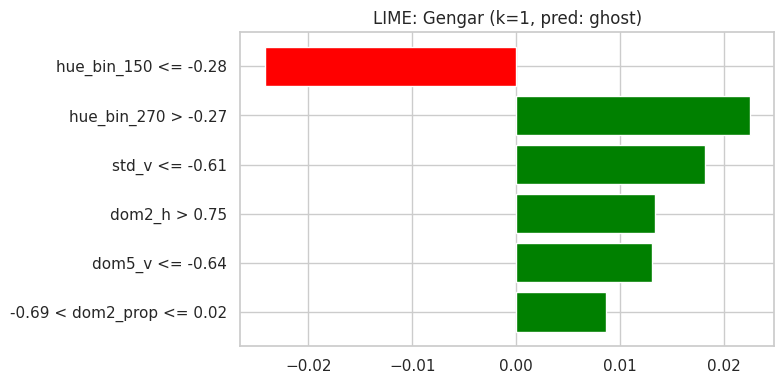

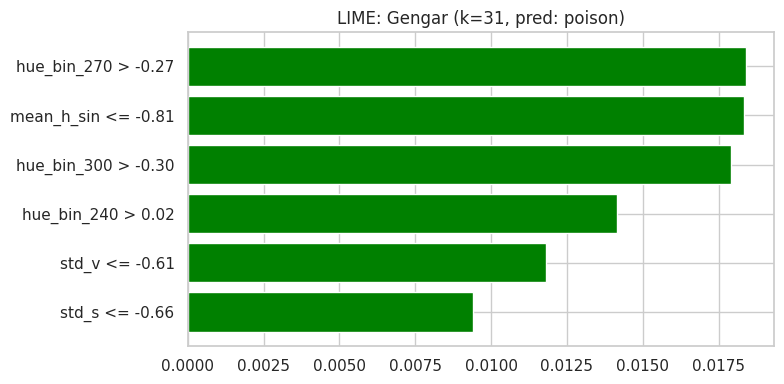

In [28]:
# Use misclass_secondary (Gengar #94) -- in the test set, ghost predicted as poison
target_id = (EXPLAIN_IDS.get("misclass_secondary")
             or next(iter(explain_cases.values())))

row_mask = df["id"] == target_id
df_pos = df[row_mask].index[0]
test_indices = split_idx["test_idx"]
row_pos_in_df = np.where(df.index == df_pos)[0][0]
test_match = np.where(test_indices == row_pos_in_df)[0]

if len(test_match) == 0:
    # Fallback: first test-set misclassification
    test_df_tmp = df.iloc[split_idx["test_idx"]].copy()
    test_df_tmp["predicted"] = y_pred
    misclass = test_df_tmp[test_df_tmp["type1_encoded"] != test_df_tmp["predicted"]]
    i = np.where(split_idx["test_idx"] == misclass.index[0])[0][0]
    target_id = int(misclass.iloc[0]["id"])
else:
    i = test_match[0]

x_instance = X_test_scaled.iloc[i]
true_type = int_to_type[int(y_test.iloc[i])]
pokemon_name = df[df["id"] == target_id].iloc[0]["name"].capitalize()

print(f"Analysing k-effect on: {pokemon_name} (true type: {true_type})")
k_values = [1, 5, 15, 31]
for k_val in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k_val, weights=knn.weights, metric=knn.metric)
    knn_k.fit(X_train_scaled, y_train)
    pred = int_to_type[int(knn_k.predict(x_instance.values.reshape(1, -1))[0])]
    print(f"  k={k_val:2d}: predicted = {pred}")

# LIME comparison for k=1 vs k=31
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_cols,
    class_names=[int_to_type[j] for j in sorted(int_to_type)],
    mode="classification",
    random_state=common.RANDOM_STATE,
)
for k_val, k_label in [(1, "k=1"), (31, "k=31")]:
    knn_k = KNeighborsClassifier(n_neighbors=k_val, weights=knn.weights, metric=knn.metric)
    knn_k.fit(X_train_scaled, y_train)
    pred_k = int(knn_k.predict(x_instance.values.reshape(1, -1))[0])
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, knn_k.predict_proba, num_features=6, top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(8, 4)
    plt.title(f"LIME: {pokemon_name} ({k_label}, pred: {int_to_type[pred_k]})")
    plt.tight_layout(); plt.show()

k=1 is the most sensitive: a single unusual neighbor can dominate the prediction, making explanations unstable. k=31 smooths over local noise but can cause errors near decision boundaries between similar types. The LIME explanations become more stable as k increases, as the decision function becomes smoother. The optimal k from GridSearch represents a trade-off between sensitivity and stability.

## 3.4 Decision Boundary Visualization (2D PCA projection)

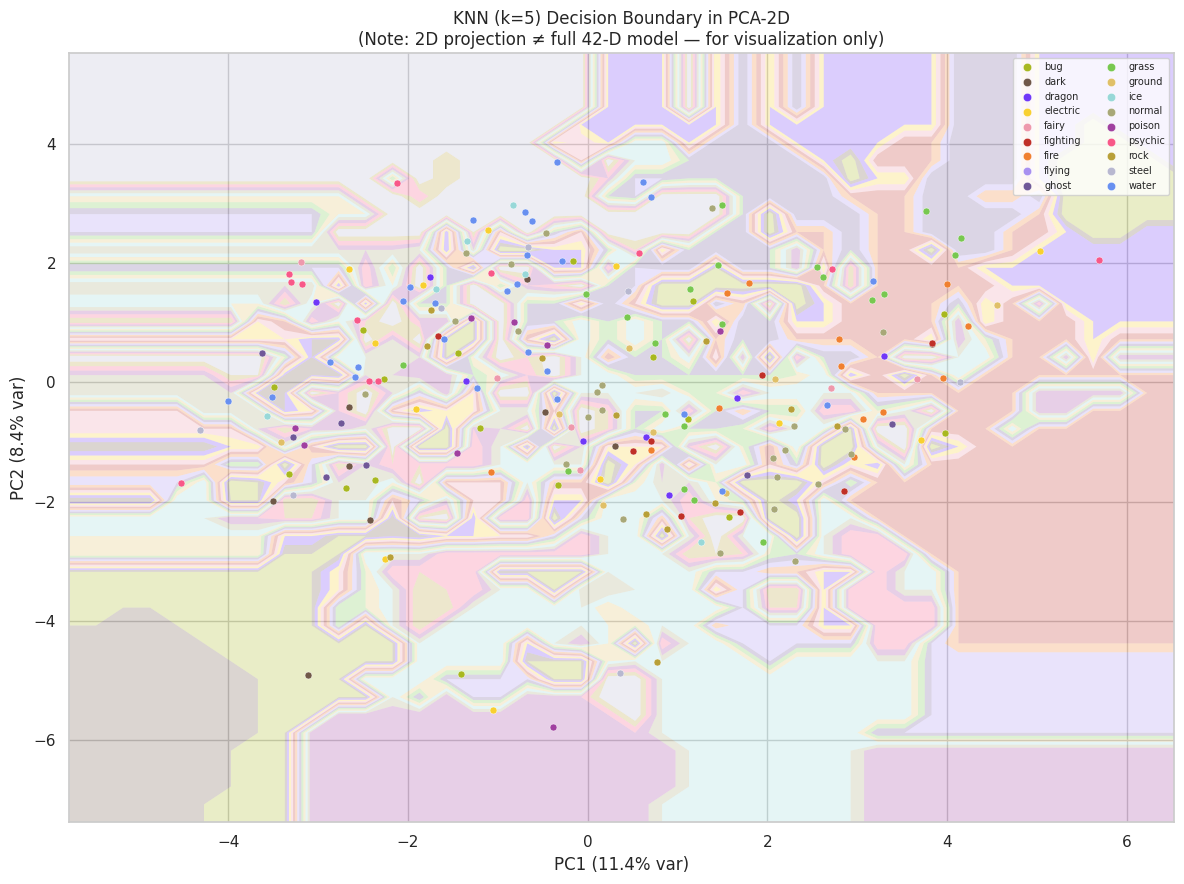

PCA retains ~30% of variance. Treat this as qualitative intuition only.


In [29]:
# Project all data to 2D PCA
pca = PCA(n_components=2, random_state=common.RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled.values)
X_test_pca  = pca.transform(X_test_scaled.values)

# Train KNN on 2D projection
knn_2d = KNeighborsClassifier(n_neighbors=knn.n_neighbors, weights=knn.weights, metric=knn.metric)
knn_2d.fit(X_train_pca, y_train)

# Decision boundary mesh
h = 0.3
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Map predictions to colors
unique_classes = sorted(int_to_type.keys())
color_list = [common.TYPE_COLORS.get(int_to_type[c], "#888") for c in unique_classes]
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(12, 9))
ax.contourf(xx, yy, Z_idx, levels=len(unique_classes)-1,
             colors=[mcolors.to_rgba(c, alpha=0.25) for c in color_list],
             antialiased=True)
for cls in unique_classes:
    mask = (y_test.values == cls)
    color = common.TYPE_COLORS.get(int_to_type[cls], "#888")
    ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
               c=color, label=int_to_type[cls], s=25, edgecolors="white", linewidths=0.3, zorder=2)
ax.legend(loc="upper right", fontsize=7, ncol=2, markerscale=1.2)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"KNN (k={knn.n_neighbors}) Decision Boundary in PCA-2D\n"
             "(Note: 2D projection \u2260 full 42-D model \u2014 for visualization only)")
plt.tight_layout(); plt.show()
print("WARNING: This 2D visualization is NOT faithful to the 42-feature model.")
print("PCA retains ~30% of variance. Treat this as qualitative intuition only.")

The 2D decision boundary shows highly fragmented regions, a characteristic of KNN with many classes. Water and Grass form recognizable clusters in PCA space. However, many types overlap heavily, confirming that 2 PCA components capture insufficient variance for reliable classification. The full 42-feature model operates in a much richer space where distances are more discriminative.

# 4. Generative AI Section

All prompts used during this project are documented below for reproducibility.